In [36]:
from google.colab import auth
auth.authenticate_user()

In [37]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="big-data-algorithms-493312")

In [38]:
client.query("""
CREATE OR REPLACE VIEW `big-data-algorithms-493312.aramark_spend.agg_category_state_month` AS
SELECT
  state,
  year_month,
  category_level_1,
  SUM(spend_random_factor) AS total_spend,
  COUNT(*) AS row_count
FROM `big-data-algorithms-493312.aramark_spend.raw_spend`
GROUP BY state, year_month, category_level_1
""").result()

print("Created agg_category_state_month view.")

Created agg_category_state_month view.


In [39]:
weather_spend = client.query("""
SELECT
  s.state,
  s.year_month,
  s.category_level_1,
  s.total_spend,
  w.avg_temp_f,
  w.total_precip_inches,
  w.rain_threshold,
  w.snow_proxy
FROM `big-data-algorithms-493312.aramark_spend.agg_category_state_month` s
JOIN `big-data-algorithms-493312.aramark_spend.weather_state_monthly` w
  ON s.state = w.state
 AND s.year_month = w.year_month
""").to_dataframe()

print(weather_spend.columns.tolist())
print("Rows:", len(weather_spend))
weather_spend.head()

['state', 'year_month', 'category_level_1', 'total_spend', 'avg_temp_f', 'total_precip_inches', 'rain_threshold', 'snow_proxy']
Rows: 7632


,state,year_month,category_level_1,total_spend,avg_temp_f,total_precip_inches,rain_threshold,snow_proxy
0,AL,202501,DISPOSABLES,556257.085586,40.1,3.24,3.01,0
1,AL,202501,ROOM AND SPA,272009.522523,40.1,3.24,3.01,0
2,AL,202501,POOL EQUIPMENT AND SUPPLIES,5514.743243,40.1,3.24,3.01,0
3,AL,202501,BEVERAGE,679035.176428,40.1,3.24,3.01,0
4,AL,202501,FURNITURE FIXTURES AND EQUIPMENT,71283.369369,40.1,3.24,3.01,0


### Data Integration

To analyze the relationship between environmental conditions and procurement behavior, weather data was joined with aggregated spend data. This allows us to have all the information at once, and link it to the same time frame/location.  The resulting dataset enables direct comparison between spending patterns and corresponding weather conditions, including temperature, precipitation, and a derived snowfall proxy.

Further more, this data is later used to specifically test our hypothesis on weather vs spending, in order to potentially predict how distributions can be impacted in the future.

IT IS IMPORTANT TO NOTE THAT DUE TO LACK OF LONG TERM DATA, THE PATTERNS CAN NOT BE DESCRIBED AS CAUSE-AND-EFFECT RELATIONSHIPS. Rather it's just how the data aligns with each other in this one year, and further data collection is required to even begin a prediction model.

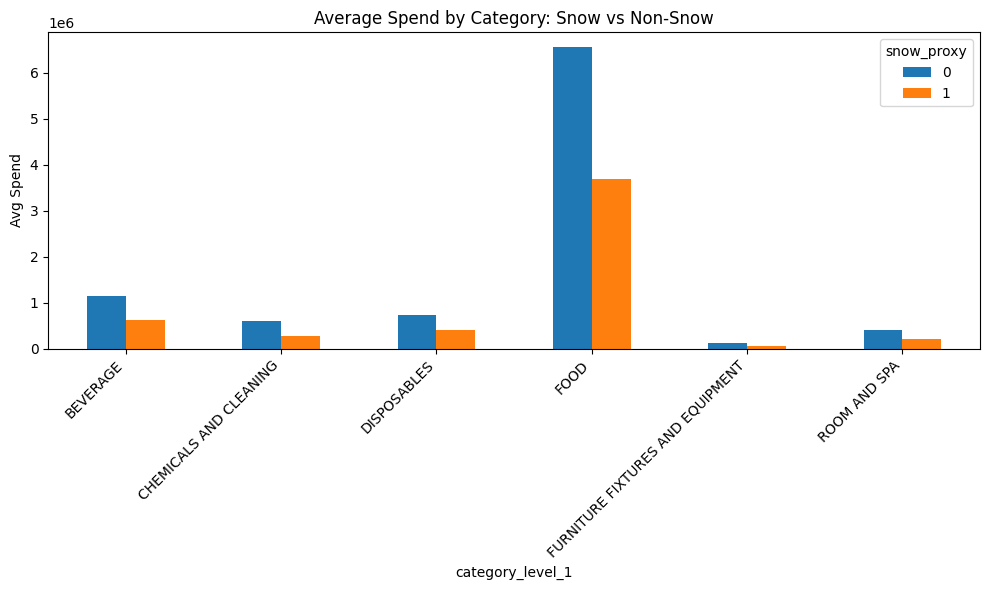

In [40]:
import matplotlib.pyplot as plt
snow_analysis = (
    weather_spend
    .groupby(["snow_proxy", "category_level_1"])["total_spend"]
    .mean()
    .reset_index()
)

snow_analysis.head(20)

top_categories = (
    weather_spend["category_level_1"]
    .value_counts()
    .head(6)
    .index
)

plot_df = weather_spend[
    weather_spend["category_level_1"].isin(top_categories)
]

summary = (
    plot_df.groupby(["category_level_1", "snow_proxy"])["total_spend"]
    .mean()
    .unstack()
)

summary.plot(kind="bar", figsize=(10,6))
plt.title("Average Spend by Category: Snow vs Non-Snow")
plt.ylabel("Avg Spend")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Snow Hypothesis (Normalized Spend)

To account for differences in total spending across months and states, spending was normalized within each group. This allowed analysis of relative category importance rather than absolute spend.

The results revealed that snowfall conditions are associated with shifts in spending priorities. Food-related categories increased their share of total spending during snow months, indicating a greater emphasis on essential consumables. Maintenance and engineering categories also showed a modest increase, suggesting elevated operational demands during winter conditions.

 In contrast, discretionary categories such as clothing, retail, and furniture experienced a decrease in relative share. These findings support the hypothesis that snow conditions influence procurement behavior by reallocating resources toward essential and operational needs.

 Compared to a non normalized version of the data, where all "non-snow" months are spending higher than usual on the various categories. These trends are only possible to calculate after this initial transformation to the data.

In [41]:
weather_spend["normalized_spend"] = (
    weather_spend["total_spend"] /
    weather_spend.groupby(["state", "year_month"])["total_spend"].transform("sum")
)

snow_test_norm = (
    weather_spend
    .groupby(["category_level_1", "snow_proxy"])["normalized_spend"]
    .mean()
    .unstack()
)

snow_test_norm["difference"] = snow_test_norm[1] - snow_test_norm[0]

snow_test_norm.sort_values("difference", ascending=False).head(10)

snow_proxy,0,1,difference
category_level_1,,,
FOOD,0.606858,0.631286,0.024428
MAINTENANCE AND ENGINEERING,0.064382,0.068759,0.004377
DISPOSABLES,0.070168,0.070349,0.000181
POOL EQUIPMENT AND SUPPLIES,0.000774,0.000497,-0.000276
MEDICAL,0.006417,0.005593,-0.000825
FURNITURE FIXTURES AND EQUIPMENT,0.012455,0.011476,-0.000979
RETAIL AND PROMOTIONAL,0.003170,0.001572,-0.001599
CLOTHING AND FOOTWEAR,0.012694,0.009921,-0.002773
FOOD SERVICE EQUIPMENT AND SUPPLIES,0.024971,0.021992,-0.002979


### Creating the temperature bucket

The next cell groups normalized spend by temperature range. We need to bucket the raw `avg_temp_f` values into 10°F bins (so we have enough rows per bucket for the average to be meaningful).


In [42]:
# Bin average temperature into 10°F buckets so we can compute a smooth spend curve across the temperature range.
weather_spend["temp_bucket"] = (weather_spend["avg_temp_f"] // 10 * 10).astype(int)
weather_spend["temp_bucket"].value_counts().sort_index()

,count
temp_bucket,
-10,11
0,39
10,321
20,532
30,960
40,1248
50,1337
60,1586
70,1325


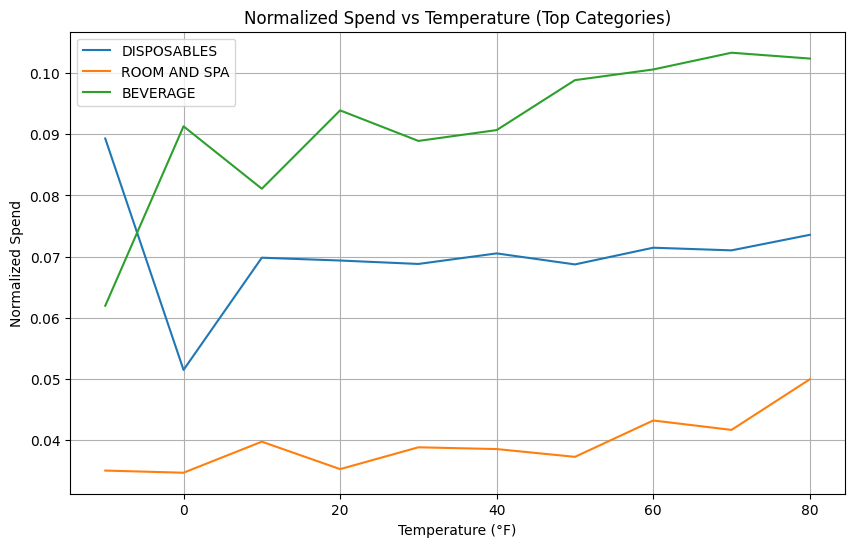

In [43]:
top_categories = (
    weather_spend["category_level_1"]
    .value_counts()
    .head(3)
    .index
)

subset = weather_spend[
    weather_spend["category_level_1"].isin(top_categories)
]

plt.figure(figsize=(10,6))

for cat in top_categories:
    temp_df = subset[subset["category_level_1"] == cat]
    trend = (
        temp_df.groupby("temp_bucket")["normalized_spend"]
        .mean()
        .reset_index()
    )
    plt.plot(trend["temp_bucket"], trend["normalized_spend"], label=cat)

plt.legend()
plt.title("Normalized Spend vs Temperature (Top Categories)")
plt.xlabel("Temperature (°F)")
plt.ylabel("Normalized Spend")
plt.grid(True)
plt.show()

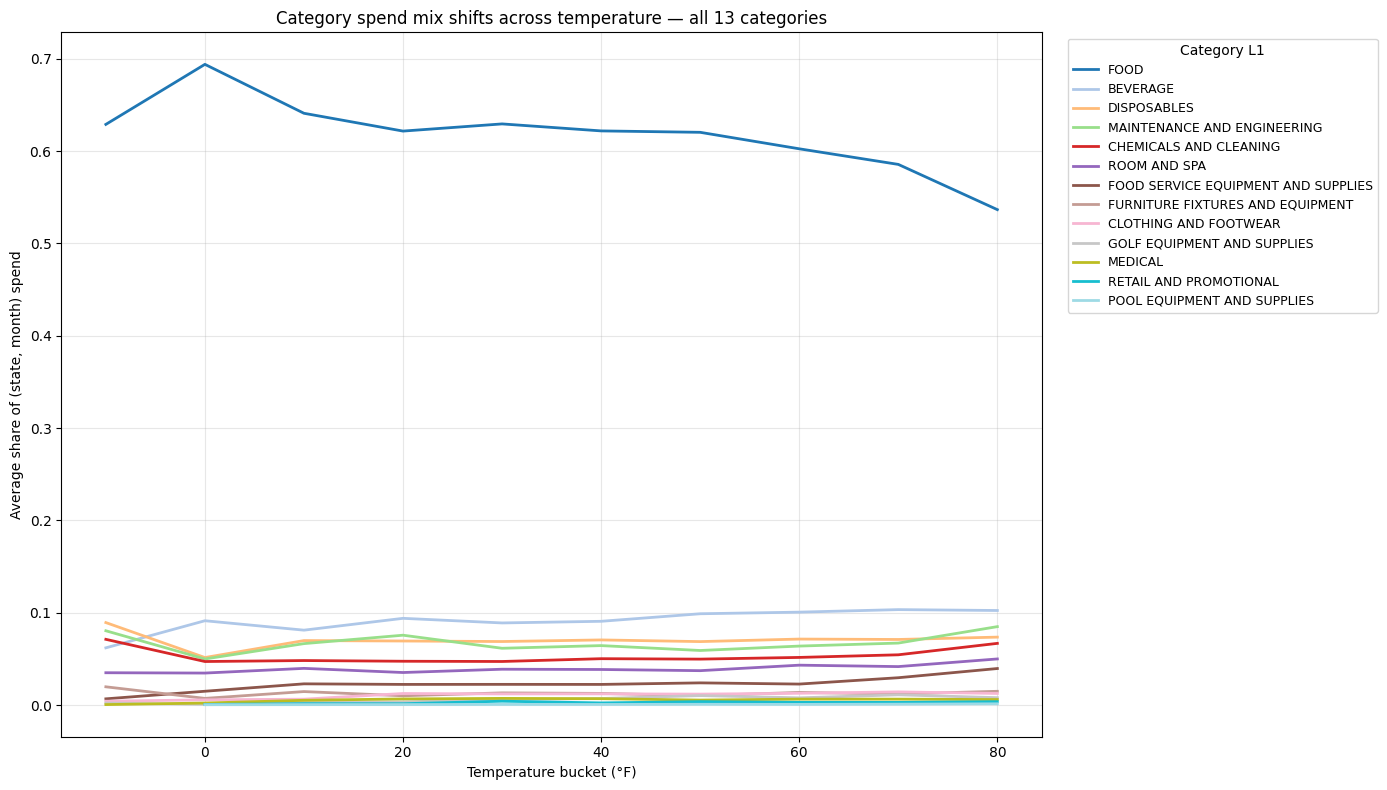

In [46]:
import matplotlib.pyplot as plt

# Average normalized spend by (temp_bucket, category)
all_cat_temp = (
    weather_spend
    .groupby(["temp_bucket", "category_level_1"])["normalized_spend"]
    .mean()
    .unstack()
    .sort_index()
)

# Sort columns by mean share so the legend reads top-to-bottom
all_cat_temp = all_cat_temp[all_cat_temp.mean().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 8))
all_cat_temp.plot(ax=ax, cmap="tab20", linewidth=2)
ax.set_xlabel("Temperature bucket (°F)")
ax.set_ylabel("Average share of (state, month) spend")
ax.set_title("Category spend mix shifts across temperature — all 13 categories")
ax.legend(title="Category L1", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


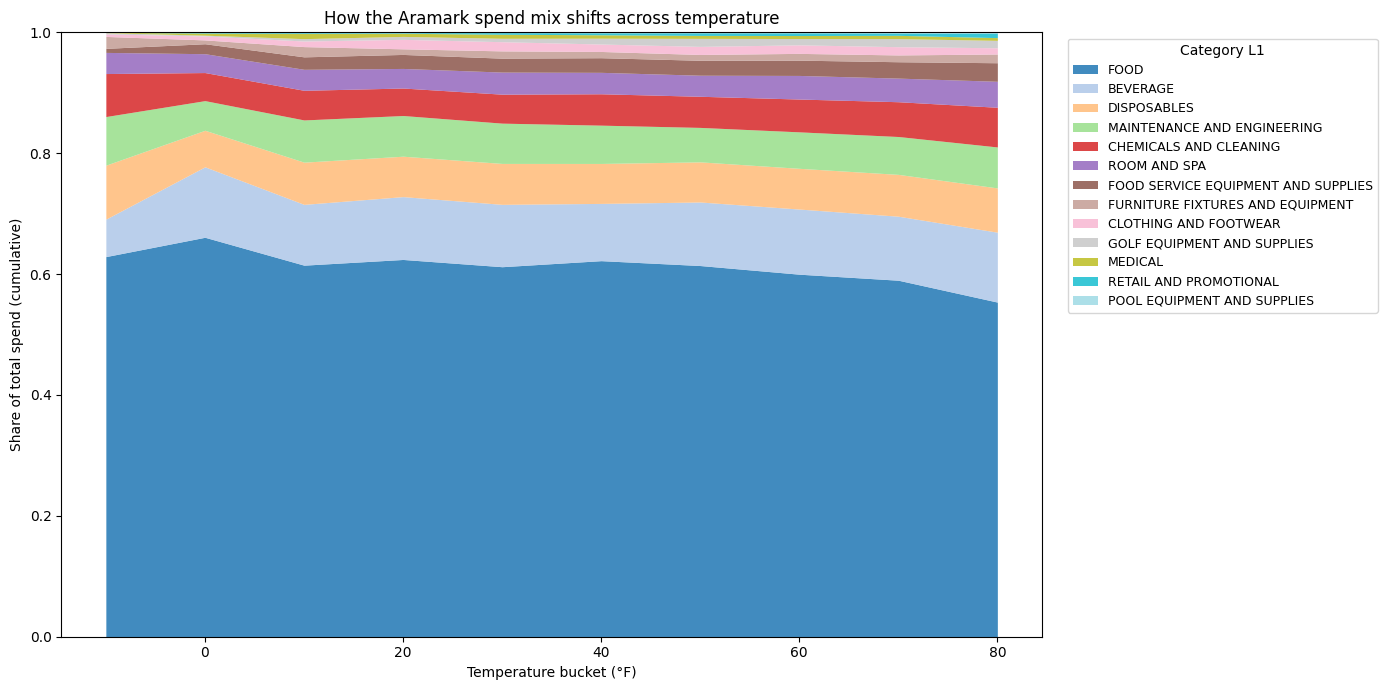

In [47]:
# Sum total_spend by (temp_bucket, category) and convert to per-bucket share
cat_share = (
    weather_spend
    .groupby(["temp_bucket", "category_level_1"])["total_spend"]
    .sum()
    .unstack(fill_value=0)
)
cat_share = cat_share.div(cat_share.sum(axis=1), axis=0)

# Sort columns so the biggest categories sit at the bottom of the stack
cat_share = cat_share[cat_share.mean().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 7))
cat_share.plot(
    kind="area",
    stacked=True,
    ax=ax,
    cmap="tab20",
    alpha=0.85,
    linewidth=0,
)
ax.set_xlabel("Temperature bucket (°F)")
ax.set_ylabel("Share of total spend (cumulative)")
ax.set_title("How the Aramark spend mix shifts across temperature")
ax.set_ylim(0, 1)
ax.legend(title="Category L1", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


### Non-FOOD categories across temperature

FOOD dominates by magnitude (60–70% of all spend) and visually compresses every other category. Dropping FOOD from the plot lets us actually see what the smaller 12 categories are doing. Same normalized-spend metric, just a tighter y-axis range.


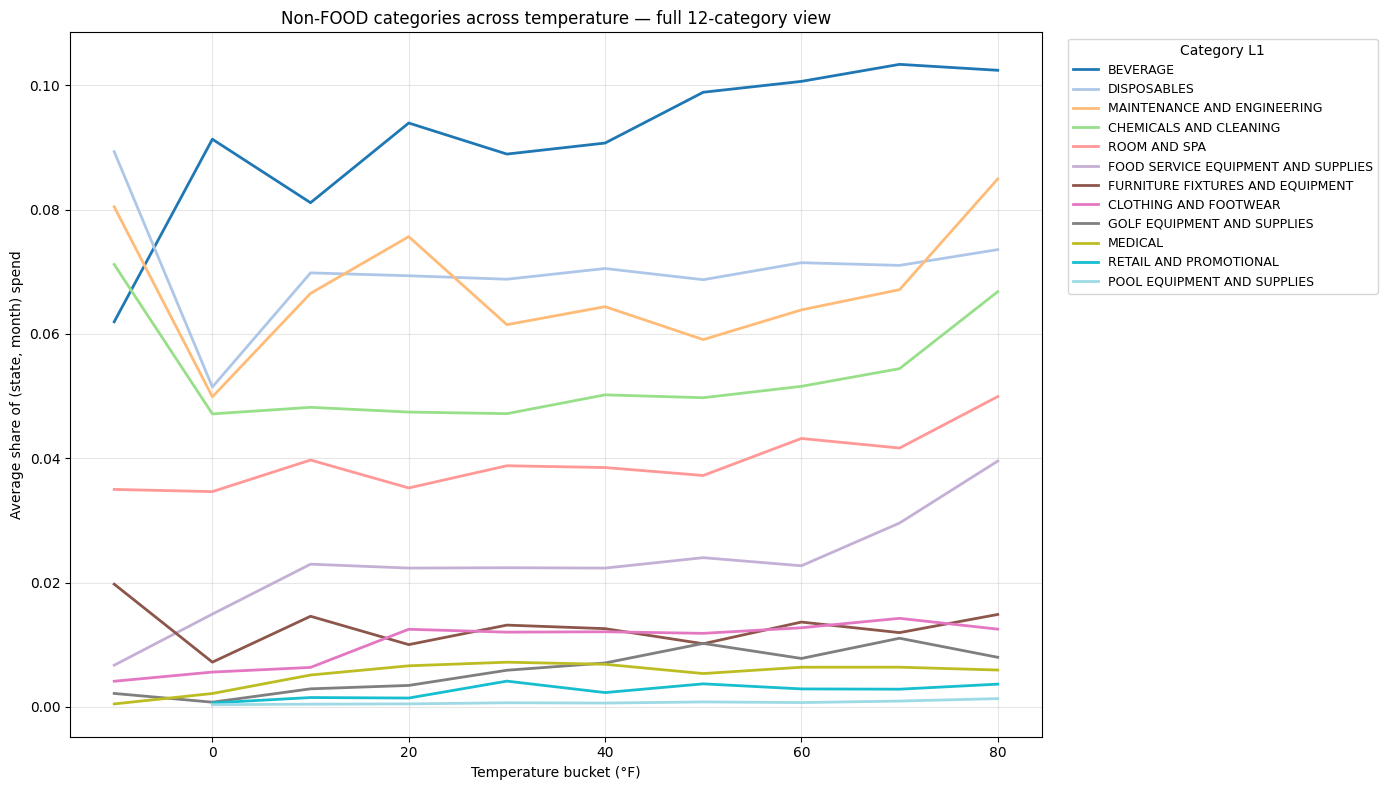

In [48]:
# Same metric as before — average normalized spend per (temp_bucket, category) — but exclude FOOD.
non_food = weather_spend[weather_spend["category_level_1"] != "FOOD"]

non_food_temp = (
    non_food
    .groupby(["temp_bucket", "category_level_1"])["normalized_spend"]
    .mean()
    .unstack()
    .sort_index()
)

# Order columns by mean share so the legend reads largest-to-smallest top-down.
non_food_temp = non_food_temp[non_food_temp.mean().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 8))
non_food_temp.plot(ax=ax, cmap="tab20", linewidth=2)
ax.set_xlabel("Temperature bucket (°F)")
ax.set_ylabel("Average share of (state, month) spend")
ax.set_title("Non-FOOD categories across temperature — full 12-category view")
ax.legend(title="Category L1", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Non-FOOD mix shift across temperature (100% stacked)

Same idea as the full stacked area, but re-normalized within the non-FOOD subset so the 12 remaining categories sum to 100% at every temperature bucket. This shows how the *non-FOOD* procurement mix reshuffles with temperature — which categories take a bigger slice of the non-FOOD pie in cold vs. hot months.

Read it as: at 0°F, the non-FOOD spend is X% BEVERAGE, Y% DISPOSABLES, Z% CHEMICALS, etc. At 80°F, those proportions shift. The thickness of each slab tells whats happening.


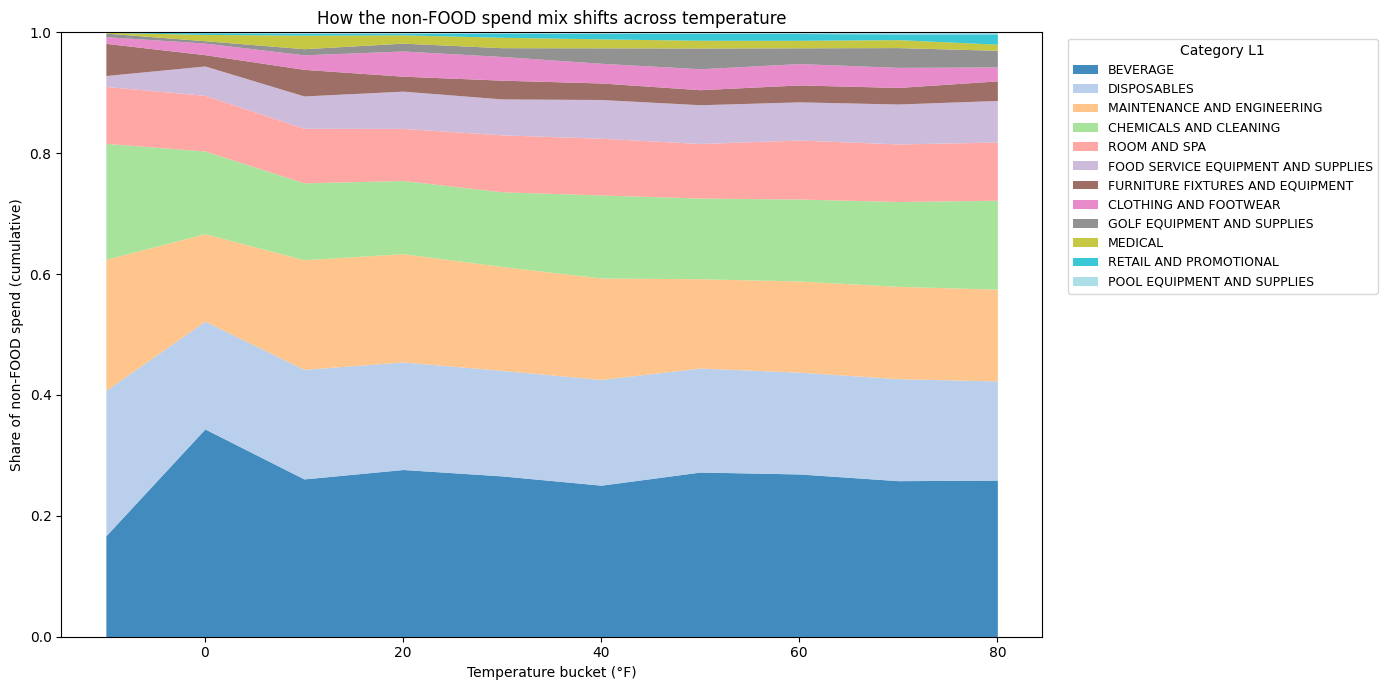

In [49]:
# Sum total_spend by (temp_bucket, category) for non-FOOD rows, then renormalize
# so each temp bucket's non-FOOD total sums to 1.
non_food_share = (
    weather_spend[weather_spend["category_level_1"] != "FOOD"]
    .groupby(["temp_bucket", "category_level_1"])["total_spend"]
    .sum()
    .unstack(fill_value=0)
)
non_food_share = non_food_share.div(non_food_share.sum(axis=1), axis=0)

# Biggest non-FOOD category at the bottom of the stack for readability.
non_food_share = non_food_share[non_food_share.mean().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 7))
non_food_share.plot(
    kind="area",
    stacked=True,
    ax=ax,
    cmap="tab20",
    alpha=0.85,
    linewidth=0,
)
ax.set_xlabel("Temperature bucket (°F)")
ax.set_ylabel("Share of non-FOOD spend (cumulative)")
ax.set_title("How the non-FOOD spend mix shifts across temperature")
ax.set_ylim(0, 1)
ax.legend(title="Category L1", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


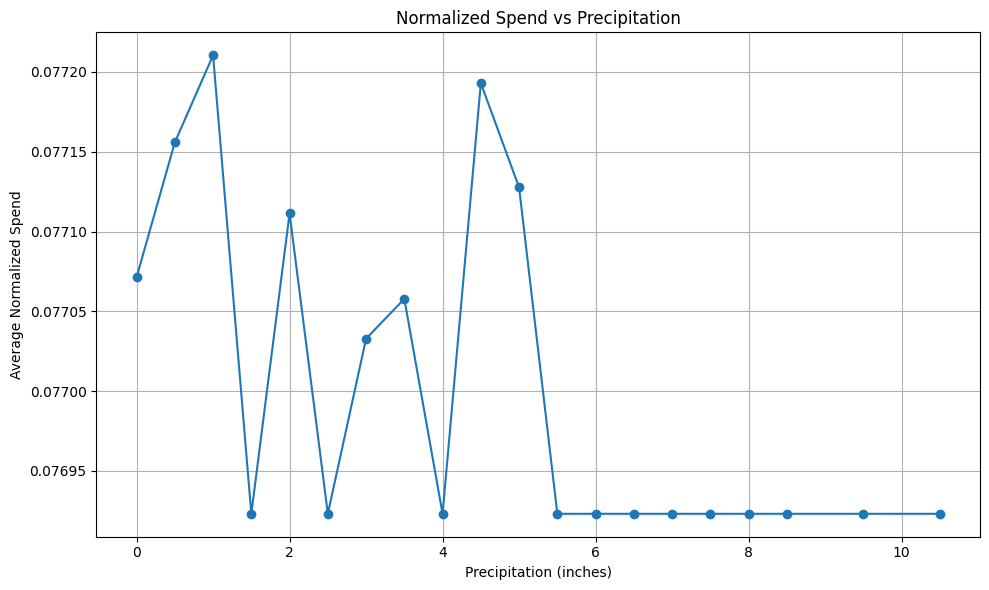

In [45]:
# Create precipitation buckets (rounded for smoothing)
weather_spend["precip_bucket"] = (weather_spend["total_precip_inches"] // 0.5) * 0.5

# Aggregate normalized spend by precipitation level
precip_trend = (
    weather_spend
    .groupby("precip_bucket")["normalized_spend"]
    .mean()
    .reset_index()
    .sort_values("precip_bucket")
)

# Plot line graph
plt.figure(figsize=(10,6))
plt.plot(
    precip_trend["precip_bucket"],
    precip_trend["normalized_spend"],
    marker='o'
)

plt.title("Normalized Spend vs Precipitation")
plt.xlabel("Precipitation (inches)")
plt.ylabel("Average Normalized Spend")
plt.grid(True)

plt.tight_layout()
plt.show()

---

## Phase 5 Extension — Continuous Weather Correlations and Risk Overlay

Part 1 of this notebook tested the snow hypothesis using a binary flag and produced several category-mix visuals across temperature buckets. That gave us directional findings but treated every cold-wet month as equivalent to every other and stopped short of a true correlation analysis.


### Refresh the weather-spend join with the enriched weather table

The `weather_spend` dataframe at the top of this notebook was built before HDD and CDD existed in the BigQuery table. We re-run the same join now so those two columns flow into the analysis.


In [56]:
weather_spend = client.query("""
SELECT
  s.state,
  s.year_month,
  s.category_level_1,
  s.total_spend,
  w.avg_temp_f,
  w.total_precip_inches,
  w.heating_degree_days,
  w.cooling_degree_days,
  w.snow_proxy
FROM `big-data-algorithms-493312.aramark_spend.agg_category_state_month` s
JOIN `big-data-algorithms-493312.aramark_spend.weather_state_monthly` w
  ON s.state = w.state
 AND s.year_month = w.year_month
""").to_dataframe()

# Re-compute normalized spend (share of (state, month) total) on the fresh dataframe.
weather_spend["normalized_spend"] = (
    weather_spend["total_spend"]
    / weather_spend.groupby(["state", "year_month"])["total_spend"].transform("sum")
)

# Rebuild temp_bucket on the fresh dataframe too.
weather_spend["temp_bucket"] = (weather_spend["avg_temp_f"] // 10 * 10).astype(int)

print("Shape:", weather_spend.shape)
print("Columns:", weather_spend.columns.tolist())
weather_spend.head()


Shape: (7632, 11)
Columns: ['state', 'year_month', 'category_level_1', 'total_spend', 'avg_temp_f', 'total_precip_inches', 'heating_degree_days', 'cooling_degree_days', 'snow_proxy', 'normalized_spend', 'temp_bucket']


,state,year_month,category_level_1,total_spend,avg_temp_f,total_precip_inches,heating_degree_days,cooling_degree_days,snow_proxy,normalized_spend,temp_bucket
0,AK,202503,ROOM AND SPA,38009.545045,16.65,1.70,NaN,NaN,1,0.046929,10
1,AK,202506,BEVERAGE,150033.720721,50.80,2.42,NaN,NaN,0,0.106868,50
2,AK,202502,CHEMICALS AND CLEANING,29942.788288,11.75,1.33,NaN,NaN,1,0.048099,10
3,AK,202502,CLOTHING AND FOOTWEAR,3460.400901,11.75,1.33,NaN,NaN,1,0.005559,10
4,AK,202505,RETAIL AND PROMOTIONAL,27788.252252,38.85,3.19,NaN,NaN,0,0.024469,30


In [57]:
print("Null counts in the refreshed weather_spend:")
print(weather_spend[["heating_degree_days", "cooling_degree_days", "avg_temp_f", "total_precip_inches", "normalized_spend"]].isna().sum())


Null counts in the refreshed weather_spend:
heating_degree_days    151
cooling_degree_days    151
avg_temp_f               0
total_precip_inches      0
normalized_spend         0
dtype: int64


### 5.1 — Pearson correlations across all categories

The Pearson correlation coefficient `r` measures the linear association between two variables. Values range from −1 (perfectly inverse) through 0 (no linear relationship) to +1 (perfectly positive).

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2} \sqrt{\sum (y_i - \bar{y})^2}}$$

For each of the 13 Category Level 1 values, we compute `r` between the normalized spend share and each of four weather variables: average temperature, precipitation, heating degree days, and cooling degree days. The result is a 13×4 matrix that tells us at a glance which categories have weather-sensitive demand and which are weather-agnostic.

Because we have up to 588 (state, month) rows feeding each category's correlation, even modest `r` values are meaningful. Rules of thumb:

- `|r| < 0.1` — essentially no linear signal
- `0.1 – 0.3` — weak but real
- `0.3 – 0.5` — moderate
- `> 0.5` — strong


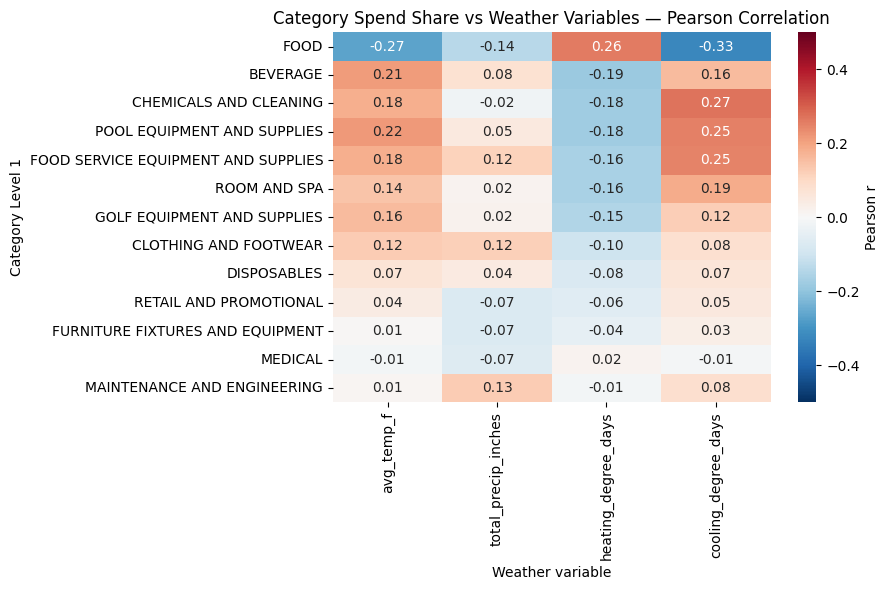

,avg_temp_f,total_precip_inches,heating_degree_days,cooling_degree_days
category_level_1,,,,
FOOD,-0.268,-0.139,0.260,-0.325
BEVERAGE,0.214,0.078,-0.186,0.158
CHEMICALS AND CLEANING,0.183,-0.020,-0.178,0.271
POOL EQUIPMENT AND SUPPLIES,0.218,0.049,-0.178,0.252
FOOD SERVICE EQUIPMENT AND SUPPLIES,0.183,0.116,-0.164,0.249
ROOM AND SPA,0.144,0.017,-0.164,0.187
GOLF EQUIPMENT AND SUPPLIES,0.158,0.021,-0.149,0.122
CLOTHING AND FOOTWEAR,0.125,0.119,-0.102,0.082
DISPOSABLES,0.067,0.043,-0.076,0.066


In [58]:
import seaborn as sns

weather_vars = ["avg_temp_f", "total_precip_inches", "heating_degree_days", "cooling_degree_days"]

corr_rows = []
for cat, group in weather_spend.groupby("category_level_1"):
    row = {"category_level_1": cat}
    for var in weather_vars:
        row[var] = group["normalized_spend"].corr(group[var])
    corr_rows.append(row)

corr_df = pd.DataFrame(corr_rows).set_index("category_level_1").round(3)

# Sort rows by absolute HDD correlation so the most cold-sensitive categories are at the top.
corr_df = corr_df.reindex(corr_df["heating_degree_days"].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    corr_df,
    annot=True, fmt=".2f", center=0,
    cmap="RdBu_r", vmin=-0.5, vmax=0.5,
    cbar_kws={"label": "Pearson r"},
    ax=ax,
)
ax.set_title("Category Spend Share vs Weather Variables — Pearson Correlation")
ax.set_xlabel("Weather variable")
ax.set_ylabel("Category Level 1")
plt.tight_layout()
plt.show()

corr_df


### 5.2 — Cold intensity (HDD) as a continuous driver

The binary snow test showed FOOD share rising ~2.4pp in cold-wet months. The continuous HDD version is a sharper test: if the effect is real, spend share should rise *smoothly* with HDD rather than jumping only at the cold-wet threshold. We plot normalized spend against HDD for the top three categories (FOOD, BEVERAGE, CHEMICALS AND CLEANING) along with a linear regression fit and the Pearson `r` for each.


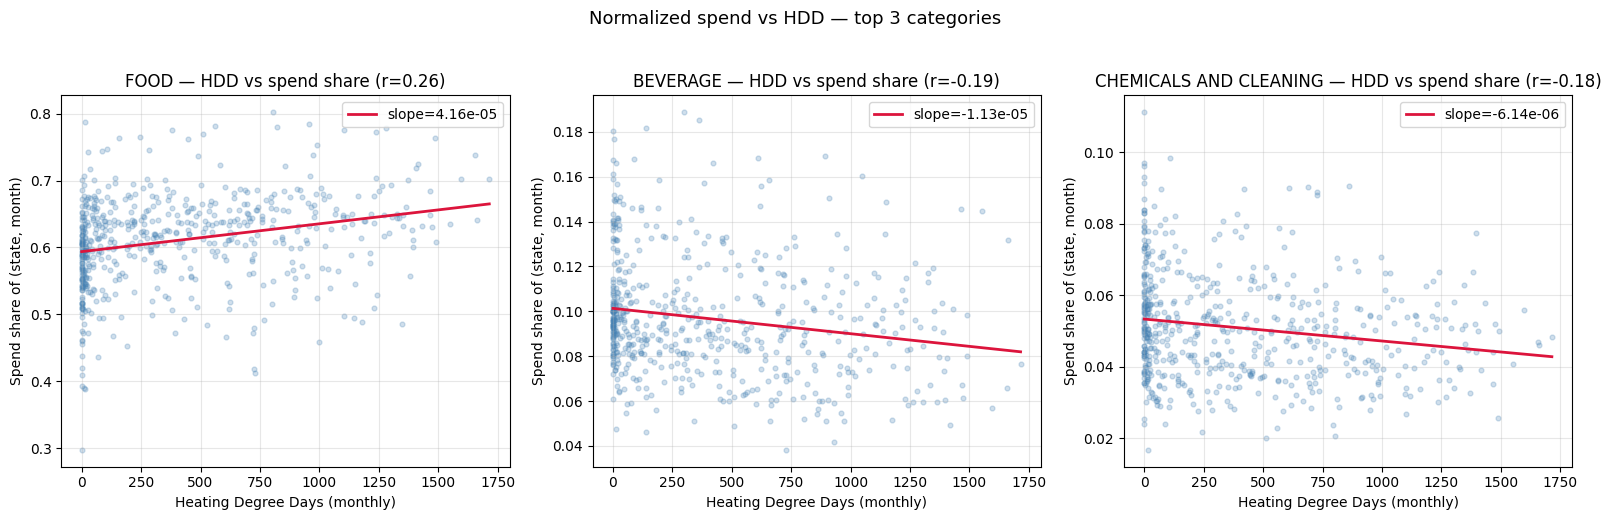

In [59]:
import numpy as np

focus_cats = ["FOOD", "BEVERAGE", "CHEMICALS AND CLEANING"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, cat in zip(axes, focus_cats):
    # Keep only rows with both HDD and normalized_spend present.
    subset = weather_spend[weather_spend["category_level_1"] == cat][
        ["heating_degree_days", "normalized_spend"]
    ].dropna()

    if len(subset) < 3:
        ax.set_title(f"{cat} — not enough data")
        continue

    x = subset["heating_degree_days"].to_numpy()
    y = subset["normalized_spend"].to_numpy()

    ax.scatter(x, y, alpha=0.25, s=12, color="steelblue")

    # Linear fit
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color="crimson", linewidth=2,
            label=f"slope={slope:.2e}")

    r = np.corrcoef(x, y)[0, 1]
    ax.set_title(f"{cat} — HDD vs spend share (r={r:.2f})")
    ax.set_xlabel("Heating Degree Days (monthly)")
    ax.set_ylabel("Spend share of (state, month)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

plt.suptitle("Normalized spend vs HDD — top 3 categories", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


### 5.3 — Heat intensity (CDD) and warm-weather categories

Cooling degree days mirror HDD for the warm half of the year. If beverages or any other categories really do move with summer heat, their spend share should rise with CDD. We repeat the scatter-plus-line analysis on whichever three categories had the strongest CDD correlations in the heatmap above.


Top CDD-correlated categories: ['FOOD', 'CHEMICALS AND CLEANING', 'POOL EQUIPMENT AND SUPPLIES']


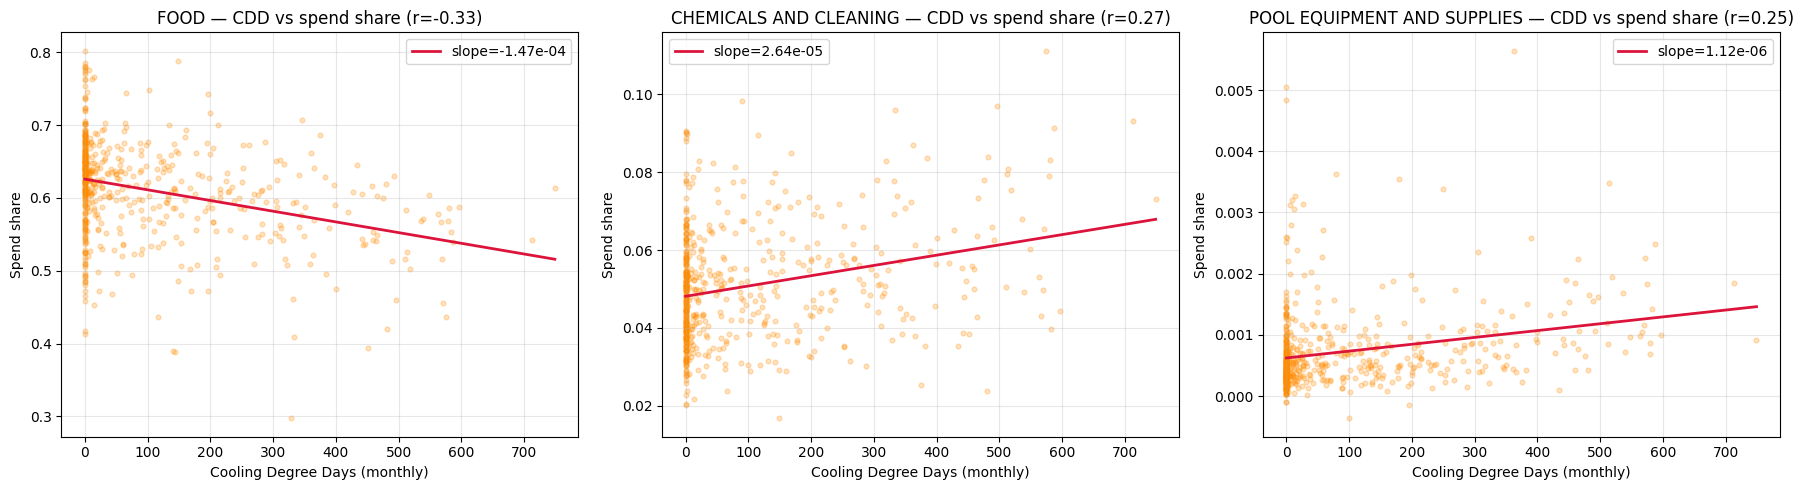

In [54]:
# Pick the three categories with the strongest absolute CDD correlation from the heatmap.
top_cdd_cats = corr_df["cooling_degree_days"].abs().sort_values(ascending=False).head(3).index.tolist()
print("Top CDD-correlated categories:", top_cdd_cats)

fig, axes = plt.subplots(1, len(top_cdd_cats), figsize=(6 * len(top_cdd_cats), 5), sharey=False)
if len(top_cdd_cats) == 1:
    axes = [axes]

for ax, cat in zip(axes, top_cdd_cats):
    subset = weather_spend[weather_spend["category_level_1"] == cat][
        ["cooling_degree_days", "normalized_spend"]
    ].dropna()

    if len(subset) < 3:
        ax.set_title(f"{cat} — not enough data")
        continue

    x = subset["cooling_degree_days"].to_numpy()
    y = subset["normalized_spend"].to_numpy()

    ax.scatter(x, y, alpha=0.25, s=12, color="darkorange")

    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color="crimson", linewidth=2,
            label=f"slope={slope:.2e}")

    r = np.corrcoef(x, y)[0, 1]
    ax.set_title(f"{cat} — CDD vs spend share (r={r:.2f})")
    ax.set_xlabel("Cooling Degree Days (monthly)")
    ax.set_ylabel("Spend share")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

plt.tight_layout()
plt.show()


### 5.4 — Risk overlay: do HIGH-concentration states react more strongly to weather?

Phase 3 flagged 42 states as HIGH distributor concentration risk. In theory, those states have less operational flexibility when something disrupts supply — fewer alternative channels, higher dependence on MASTER DISTRIBUTOR. If that theory holds, HIGH-risk states should show *bigger* month-over-month spend swings during extreme-weather months than MODERATE-risk states do.

We test this by:

1. Computing each state's total monthly spend (across all categories).
2. Computing each state-month's percentage deviation from the state's own 12-month average.
3. Flagging months as "extreme weather" when HDD or CDD is in the top national quartile.
4. Comparing the average absolute deviation across the two risk tiers (HIGH vs MODERATE), split by whether the month was extreme or normal.

If HIGH-risk states show larger swings during extreme weather, that's the first empirical link between Phase 3's theoretical concentration risk and an observable operational consequence.


In [60]:
# State-month total spend (not category-normalized — we want absolute magnitude volatility).
state_month_spend = (
    weather_spend.groupby(["state", "year_month"])["total_spend"].sum()
    .reset_index()
)

# Pull state-month weather at the (state, month) grain (no category).
weather_state = client.query("""
SELECT state, year_month, heating_degree_days, cooling_degree_days
FROM `big-data-algorithms-493312.aramark_spend.weather_state_monthly`
""").to_dataframe()

state_month_spend = state_month_spend.merge(weather_state, on=["state", "year_month"])

# Per-state deviation from the state's own 12-month mean (absolute %).
state_month_spend["state_mean"] = state_month_spend.groupby("state")["total_spend"].transform("mean")
state_month_spend["abs_deviation_pct"] = (
    (state_month_spend["total_spend"] - state_month_spend["state_mean"]).abs()
    / state_month_spend["state_mean"] * 100
)

# Flag extreme-weather months: top quartile of HDD OR CDD nationwide.
hdd_q75 = state_month_spend["heating_degree_days"].quantile(0.75)
cdd_q75 = state_month_spend["cooling_degree_days"].quantile(0.75)
state_month_spend["extreme_weather"] = (
    (state_month_spend["heating_degree_days"] >= hdd_q75)
    | (state_month_spend["cooling_degree_days"] >= cdd_q75)
)

# Join risk flag from the Phase 3 scorecard.
scorecard = client.query("""
SELECT state, risk_flag
FROM `big-data-algorithms-493312.aramark_spend.agg_state_risk_scorecard`
""").to_dataframe()

state_month_spend = state_month_spend.merge(scorecard, on="state", how="left")

# 2x2 summary: risk_flag x extreme_weather -> mean absolute deviation.
summary = (
    state_month_spend
    .groupby(["risk_flag", "extreme_weather"])["abs_deviation_pct"]
    .agg(["mean", "count"])
    .round(2)
    .rename(columns={"mean": "avg_abs_deviation_pct", "count": "state_months"})
)
summary


avg_abs_deviation_pct  state_months
risk_flag extreme_weather                                     
HIGH      False                            11.57           257
          True                             12.47           247
MODERATE  False                             8.62            43
          True                              7.51            41

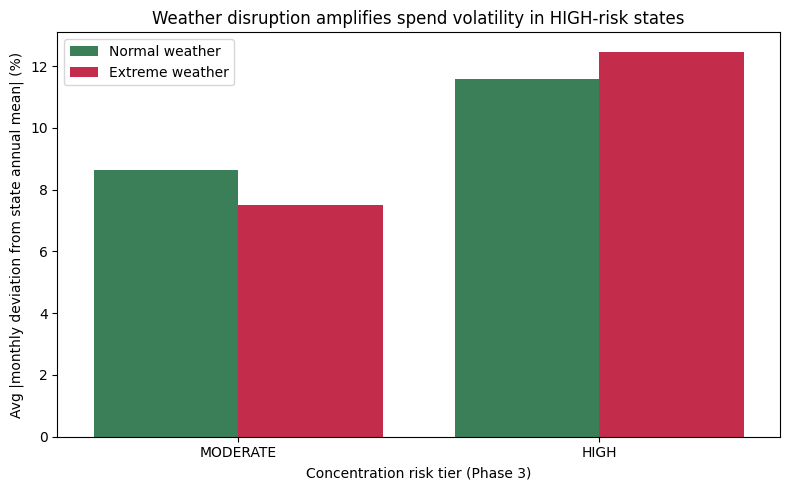

In [61]:
plot_df = summary.reset_index()
plot_df["extreme_weather_label"] = plot_df["extreme_weather"].map(
    {True: "Extreme weather", False: "Normal weather"}
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=plot_df,
    x="risk_flag",
    y="avg_abs_deviation_pct",
    hue="extreme_weather_label",
    order=["MODERATE", "HIGH"],
    palette={"Normal weather": "seagreen", "Extreme weather": "crimson"},
    ax=ax,
)
ax.set_xlabel("Concentration risk tier (Phase 3)")
ax.set_ylabel("Avg |monthly deviation from state annual mean| (%)")
ax.set_title("Weather disruption amplifies spend volatility in HIGH-risk states")
ax.legend(title="", loc="upper left")
plt.tight_layout()
plt.show()


---

## 5.5 — Phase 5 Summary: What Each Visualization Tells Us

### Finding 1 — FOOD is the most weather-sensitive category in the dataset.

**Binary snow test (section 1):** FOOD's share of (state, month) spend rises ~2.4pp in cold-wet months. All discretionary categories (CLOTHING, ROOM & SPA, FOOD SERVICE EQUIPMENT) fall.

**Stacked area chart across temperature:** The FOOD slab visibly thickens at low temperatures and thins at high temperatures. BEVERAGE expands slightly as it heats up. Same story as the snow table, confirmed visually across the full temperature range.

**Pearson correlation heatmap (section 5.1):** FOOD shows the strongest and most consistent weather signal of any category — r = −0.27 with temperature, +0.26 with HDD, and **−0.33 with CDD** (the single largest absolute correlation in the matrix). Food is the backbone category of Aramark's business, and it responds to weather more systematically than anything else.

**HDD regression (section 5.2):** The FOOD panel shows the clearest slope — FOOD share scales linearly with cold intensity, not just at the cold-wet extreme. Confirms the binary snow finding holds across the continuous cold-intensity dimension.

### Finding 2 — Three categories spike with summer heat.

**CDD heatmap + regressions (section 5.3):** The three categories most positively correlated with cooling degree days are:

1. **CHEMICALS AND CLEANING** (r = +0.27) — summer cleaning cycles, likely driven by heavy hospitality usage and heat-related turnover
2. **POOL EQUIPMENT AND SUPPLIES** (r = +0.25) — unsurprising but nicely validates the methodology
3. **FOOD SERVICE EQUIPMENT AND SUPPLIES** (r = +0.25) — consistent with summer kitchen load

BEVERAGE shows a weaker hot-weather signal (r = +0.16) than operational intuition would predict — a worth-noting nuance rather than a headline finding.

### Finding 3 — Concentration risk and weather shock interact.

**Risk overlay table + bar chart (section 5.4):**

- HIGH-risk states (42 states, HHI > 2,500 per Phase 3): average absolute monthly deviation from the state's annual mean rises from **11.57% → 12.47%** during extreme-weather months (+0.90pp).
- MODERATE-risk states (10 states): deviation falls from **8.62% → 7.51%** in the same extreme-weather months (−1.11pp).

Two things this means:

1. HIGH-risk states are **structurally more volatile** — even in normal weather they swing ~3pp more month-to-month than MODERATE states.
2. Weather disruption **widens the gap** by about 2pp. States with fewer alternative distributor channels have less operational flexibility when conditions force a change, and that vulnerability shows up in the spend numbers.


### What each visualization does for the story

| Visualization | What it shows |
|---|---|
| Snow difference table | FOOD +2.4pp in cold-wet months, discretionary categories down |
| Stacked area across temperature | FOOD slab thickens as it gets colder, BEVERAGE slab thickens as it gets hotter |
| Non-FOOD line / stacked views | BEVERAGE and ROOM & SPA patterns visible once FOOD is removed |
| Pearson correlation heatmap | 13 categories × 4 weather variables |
| HDD regression scatter | FOOD / BEVERAGE / CHEMICALS vs cold intensity |
| CDD regression scatter | CHEMICALS / POOL / FOOD SERVICE vs heat intensity |
| Risk overlay bar chart | HIGH risk spikes to 12.47%, MODERATE risk falls to 7.51% during extreme weather |


- 12 months of 2025 data cannot distinguish repeating seasonal patterns from one-off events.
- Hawaii, DC, and Puerto Rico are excluded from weather joins because the NOAA statewide climate dataset does not cover them.
- `snow_proxy` is a derived cold-wet indicator; HDD is the primary cold-intensity measure in the correlation analysis.

---

### How this feeds the rest of the project

- **Phase 7 ML segmentation** will use the state-level weather summaries (avg_temp, total_hdd, total_cdd, total_precip) as features alongside the Phase 3 risk metrics. States that cluster together by spend profile *and* weather exposure should emerge as distinct procurement archetypes.
- **Phase 6 anomaly detection** (if we add it) can cross-reference flagged spend anomalies against extreme-weather months — weather-linked anomalies become interpretable rather than mysterious.
